<a href="https://colab.research.google.com/github/janani26121992/AI-Projects/blob/main/Mobile_Price_Prediciton_model_using_ANN_using_batch_normalisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mobile Price Prediction Model using ANN


**Data** **Gathering**

In [1]:
import pandas as pd
path=r"https://raw.githubusercontent.com/janani26121992/Datasets/refs/heads/main/mobile_train%20(1).csv"
df=pd.read_csv(path)
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


# Perform basic data quality checks

In [2]:
df.shape

(2000, 21)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [4]:
df.duplicated().sum()

np.int64(0)

# Separate X and Y features

In [5]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [6]:
X=df.drop(columns=['price_range'])
Y=df[['price_range']]

In [7]:
X.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0


In [8]:
Y.head()

,price_range
0,1
1,2
2,2
3,2
4,1


In [9]:
df['price_range'].unique()

array([1, 2, 3, 0])

Mobile Price Range:

0 : cheap 1: moderate 2: Mid range 3: Expensive

Feature Engg : Data Preprocessing - Data Cleaning and Data Scaling

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
pre=make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
).set_output(transform='pandas')

In [11]:
X_pre=pre.fit_transform(X)
X_pre

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,-0.902597,-0.990050,0.830779,-1.019184,-0.762495,-1.043966,-1.380644,0.340740,1.349249,-1.101971,-1.305750,-1.408949,-1.146784,0.391703,-0.784983,0.283103,1.462493,-1.786861,-1.006018,0.986097
1,-0.495139,1.010051,-1.253064,0.981177,-0.992890,0.957886,1.155024,0.687548,-0.120059,-0.664768,-0.645989,0.585778,1.704465,0.467317,1.114266,-0.635317,-0.734267,0.559641,0.994018,-1.014099
2,-1.537686,1.010051,-1.253064,0.981177,-0.532099,0.957886,0.493546,1.381165,0.134244,0.209639,-0.645989,1.392684,1.074968,0.441498,-0.310171,-0.864922,-0.368140,0.559641,0.994018,-1.014099
3,-1.419319,1.010051,1.198517,-1.019184,-0.992890,-1.043966,-1.215274,1.034357,-0.261339,0.646842,-0.151168,1.286750,1.236971,0.594569,0.876859,0.512708,-0.002014,0.559641,-1.006018,-1.014099
4,1.325906,1.010051,-0.395011,-1.019184,2.002254,0.957886,0.658915,0.340740,0.021220,-1.101971,0.673534,1.268718,-0.091452,-0.657666,-1.022389,-0.864922,0.730240,0.559641,0.994018,-1.014099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,-1.011860,1.010051,-1.253064,0.981177,-0.992890,0.957886,-1.656260,1.034357,-0.967737,0.646842,0.673534,1.300273,1.477661,-1.342799,0.164641,-0.405712,1.462493,0.559641,0.994018,-1.014099
1996,1.653694,1.010051,1.321096,0.981177,-0.992890,-1.043966,0.383299,-1.046495,1.320993,-0.227564,-1.140810,0.608317,1.651235,-0.085031,-0.310171,0.971917,0.913303,0.559641,0.994018,0.986097
1997,1.530773,-0.990050,-0.762748,0.981177,-0.762495,0.957886,0.217930,0.687548,-0.911225,1.521249,-1.140810,0.502383,0.880565,0.860139,-0.784983,-1.094526,-1.100394,0.559641,0.994018,-1.014099
1998,0.622527,-0.990050,-0.762748,-1.019184,-0.071307,0.957886,0.769162,-1.393304,0.134244,0.209639,-0.810929,-0.696707,-1.345816,-1.157454,1.351672,0.971917,1.462493,0.559641,0.994018,0.986097


Split the data into training and testing

In [12]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X_pre,Y,train_size=0.75,random_state=42)

Multiclass classification : Y feature has multi classes ranging from 0-3. You must do encoding of Y feature before training the model so that it gets all the class labels for learning and predictions
You have to do onehot coding for Y feature

in this project, we have 4 classes to be predicted. y : [1] y: [0]

y : [0,0,0,1] y: [1,0,0,0]

In [13]:
from keras.utils import to_categorical
ytrain_cat = to_categorical(ytrain)
ytest_cat = to_categorical(ytest)

# Model Building

In [14]:
from keras.models import Sequential
from keras.layers import Input,Dense,BatchNormalization
from keras.callbacks import EarlyStopping

In [15]:
# Intialize the model
model = Sequential()

# Add the Input layer
model.add(Input(shape=(xtrain.shape[1],)))

# Add the Hidden layer 1
model.add(Dense(units=32,activation='relu'))

# Add the batch normalisation
model.add(BatchNormalization())

# Add the Hidden layer2
model.add(Dense(units=16,activation='relu'))

# Add the BatchNormalization()
model.add(BatchNormalization())

# Add the Output layer
model.add(Dense(units=ytrain_cat.shape[1],activation='softmax'))

In [16]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss',patience=10)

In [17]:
nn=model.fit(xtrain,ytrain_cat,validation_split=0.2,epochs=200,callbacks=[es])

Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.2850 - loss: 1.6619 - val_accuracy: 0.3600 - val_loss: 1.4596
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3983 - loss: 1.3580 - val_accuracy: 0.4233 - val_loss: 1.3092
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4858 - loss: 1.1892 - val_accuracy: 0.5000 - val_loss: 1.1815
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5567 - loss: 1.0513 - val_accuracy: 0.5467 - val_loss: 1.0561
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5942 - loss: 0.9468 - val_accuracy: 0.5967 - val_loss: 0.9412
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6583 - loss: 0.8343 - val_accuracy: 0.6500 - val_loss: 0.8348
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6883 - loss: 0.7461 - val_accuracy: 0.6733 - val_loss: 0.7488
Epoch 8/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7150 - loss: 0.6675 - val_accuracy: 0.

# Learning Curve

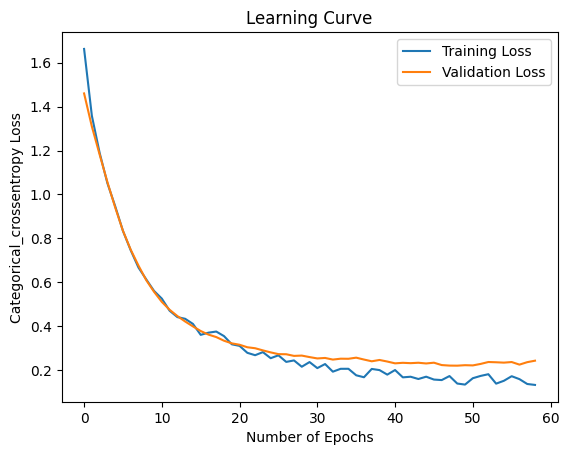

In [18]:
import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label='Training Loss')
plt.plot(nn.history['val_loss'],label='Validation Loss')
plt.title("Learning Curve")
plt.xlabel("Number of Epochs")
plt.ylabel("Categorical_crossentropy Loss")
plt.legend()
plt.show()

In [19]:
model.evaluate(xtrain,ytrain_cat)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9787 - loss: 0.0892


[0.08921096473932266, 0.9786666631698608]

In [20]:
model.evaluate(xtest,ytest_cat)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8800 - loss: 0.2543 


[0.254270076751709, 0.8799999952316284]

# Confusion matrix and Classification report

In [21]:
yprob=model.predict(xtest)
yprob

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


array([[7.6384836e-01, 2.3595631e-01, 4.8173562e-05, 1.4716809e-04],
       [3.8018520e-06, 1.1949845e-01, 8.4206045e-01, 3.8437262e-02],
       [1.1117671e-01, 8.7853003e-01, 1.0129490e-02, 1.6381950e-04],
       ...,
       [3.6365494e-05, 4.6249838e-03, 6.0067374e-01, 3.9466491e-01],
       [7.2616223e-07, 3.4562956e-07, 1.2013268e-04, 9.9987876e-01],
       [1.9296049e-01, 8.0547637e-01, 1.4372943e-03, 1.2579627e-04]],
      dtype=float32)

In [22]:
yprob[0]

array([7.6384836e-01, 2.3595631e-01, 4.8173562e-05, 1.4716809e-04],
      dtype=float32)

In [23]:
import numpy as np
np.argmax(yprob[0])

np.int64(0)

In [24]:
ypreds=[]
for i in yprob:
    pos=np.argmax(i)
    ypreds.append(pos)
ypreds

[np.int64(0),
 np.int64(2),
 np.int64(1),
 np.int64(3),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(3),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(2),
 np.int64(2),
 np.int64(3),
 np.int64(3),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(0),
 np.int64(1),
 np.int64(3),
 np.int64(3),
 np.int64(2),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(3),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(0),
 np.int64(3),
 np.int64(0),
 np.int64(1),
 np.int64(3),
 np.int64(2),
 np.int64(0),
 np.int64(2),
 np.int64(3),
 np.int64(2),
 np.int64(1),
 np.int64(3),
 np.int64(1),
 np.int64(3),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(3),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(3),
 np.int64(3),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(3),
 np.int64(3),
 np.int64(1),
 np.int64(2),
 np.int64(1),
 np.in

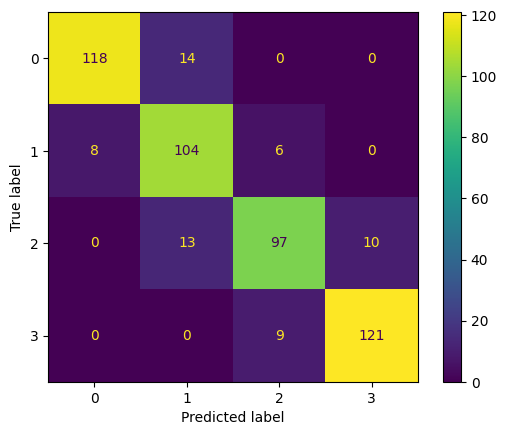

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report
ConfusionMatrixDisplay.from_predictions(ytest,ypreds)

In [26]:
print(classification_report(ytest,ypreds))

              precision    recall  f1-score   support

           0       0.94      0.89      0.91       132
           1       0.79      0.88      0.84       118
           2       0.87      0.81      0.84       120
           3       0.92      0.93      0.93       130

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



# Model is providing an accuracy of 88% in testing. We can consider this model for final predictions


In [30]:
model.save("MobilePredictionscopy.keras")

In [31]:
from keras.models import load_model
m1 = load_model("/content/MobilePredictionscopy.keras")
m1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,190 (16.37 KB)

 Trainable params: 1,364 (5.33 KB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 2,730 (10.67 KB)